# Random Walk: TD(λ) Prediction

This notebook implements the classic **random walk** example from Sutton & Barto
(Chapter 6 / Chapter 12) — the central illustration of **Temporal-Difference (TD)
learning for prediction**.

## Problem Setup
- **5 non‑terminal states**: A, B, C, D, E  (indices 0‑4)
- **Start**: always state **C** (the centre)
- **Transitions**: at each step, 50 % left, 50 % right
- **Left terminal** (past A): reward **0**
- **Right terminal** (past E): reward **+1**
- **All intermediate rewards**: 0

## What we do
1. Derive the **true values** analytically
2. Implement **TD(0)** and watch the estimates converge online
3. Implement **TD(λ)** with backward‑view eligibility traces
4. Reproduce the classic **λ‑sweep** figure (RMS error vs λ)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple

np.random.seed(42)

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12

## 1. The Random Walk Environment

The environment is a finite Markov chain with two absorbing barriers.
Because the policy is fixed (random walk), we only need to worry about
**prediction** — estimating the value of each state under the random policy.

0 (A) ← 1 (B) ← 2 (C) → 3 (D) → 4 (E)

In [31]:
class RandomWalk:
    def __init__(self, n_states: int = 5, left_reward: float = 0.0, right_reward: float = 1.0):
        self.n_states = n_states
        self.start_state = n_states // 2  # centre
        self.left_reward = left_reward
        self.right_reward = right_reward

    def reset(self) -> int:
        self.state = self.start_state
        return self.state

    def step(self) -> tuple[int | None, float, bool]:
        if np.random.random() < 0.5:
            self.state -= 1  # left
        else:
            self.state += 1  # right

        if self.state < 0:  # left terminal
            return None, self.left_reward, True
        elif self.state >= self.n_states:  # right terminal
            return None, self.right_reward, True
        else:
            return self.state, 0.0, False

    def generate_episode(self) -> tuple[list[int], float]:
        state = self.reset()
        states = [state]
        done = False
        while not done:
            next_state, reward, done = self.step()
            if not done:
                states.append(next_state)
            else:
                final_reward = reward
        return states, final_reward


# Quick demo
env = RandomWalk()
states, reward = env.generate_episode()
state_labels = ["A", "B", "C", "D", "E"]
print("Episode:", " → ".join(state_labels[s] for s in states))
print(f"Final reward: {reward}")

Episode: C → B → C → D → E → D → C → B → C → D → E → D → E
Final reward: 1.0


## 2. True Values (Analytical Solution)

Because γ = 1 and the only reward is +1 for hitting the right barrier,
the **true value of each state equals the probability of reaching the right
barrier from that state**.

For a symmetric random walk with absorbing barriers at 0 and N+1,
the probability of hitting the right barrier from state *i* is:

$$V(s_i) = \frac{i+1}{N+1}$$

In [32]:
def true_values(n_states: int = 5) -> np.ndarray:
    return np.array([(i + 1) / (n_states + 1) for i in range(n_states)])


V_true = true_values()
state_labels = ["A", "B", "C", "D", "E"]

print("True values:")
for lbl, v in zip(state_labels, V_true):
    print(f"  V({lbl}) = {v:.4f} = {v:.3g}")

True values:
  V(A) = 0.1667 = 0.167
  V(B) = 0.3333 = 0.333
  V(C) = 0.5000 = 0.5
  V(D) = 0.6667 = 0.667
  V(E) = 0.8333 = 0.833


## 3. First-Visit MC vs Every-Visit MC

Monte Carlo methods wait until the end of an episode, then update the value
of each state visited toward the **actual return** \(G_t\) observed from
that state:

$$V(S_t) \leftarrow V(S_t) + \alpha \big[ G_t - V(S_t) \big]$$

The two variants differ only in **which occurrences** of a state get updated:

- **Every-visit MC**: updates \(V(s)\) for *every* occurrence of \(s\) in
  the episode.  Revisited states get multiple updates from the same return.
- **First-visit MC**: updates \(V(s)\) only for the *first* occurrence of
  \(s\).  Each state gets at most one update per episode.

In the random walk (γ = 1, only terminal rewards), \(G_t\) equals the
terminal reward for every time step — either 0 or +1.  The difference
between the two variants matters here because episodes can revisit the
centre states (B, C, D) multiple times.

In [33]:
def mc_first_visit(
    alpha: float = 0.1,
    n_episodes: int = 100,
    n_states: int = 5,
    seed: int | None = None,
    initial_value: float = 0.0,
) -> np.ndarray:
    if seed is not None:
        np.random.seed(seed)

    env = RandomWalk(n_states)
    V = np.full(n_states, initial_value)
    V_history = np.zeros((n_episodes, n_states))

    for ep in range(n_episodes):
        states, final_reward = env.generate_episode()

        # First-visit MC: only update the first occurrence of each state
        G = final_reward
        seen = set()
        for state in states:
            if state not in seen:
                V[state] += alpha * (G - V[state])
                seen.add(state)

        V_history[ep] = V.copy()

    return V_history

In [34]:
def mc_every_visit(
    alpha: float = 0.1,
    n_episodes: int = 100,
    n_states: int = 5,
    seed: int | None = None,
    initial_value: float = 0.0,
) -> np.ndarray:
    if seed is not None:
        np.random.seed(seed)

    env = RandomWalk(n_states)
    V = np.full(n_states, initial_value)
    V_history = np.zeros((n_episodes, n_states))

    for ep in range(n_episodes):
        states, final_reward = env.generate_episode()

        # Every-visit MC: the return G_t = final_reward for every state
        G = final_reward
        for state in states:
            V[state] += alpha * (G - V[state])

        V_history[ep] = V.copy()

    return V_history

In [35]:
# ── Illustrate the difference on a single episode ──
env = RandomWalk()
states, reward = env.generate_episode()

# Count visits per state
from collections import Counter

visit_counts = Counter(states)

print("Single episode:", " → ".join(state_labels[s] for s in states))
print(f"Final reward: {reward}\n")
print("Update counts per state in this episode:")
print(f"{'State':>6s}  {'Visits':>7s}  {'Every-visit':>12s}  {'First-visit':>12s}")
print("-" * 45)
for i, lbl in enumerate(state_labels):
    count = visit_counts.get(i, 0)
    ev = f"{count} update(s)" if count > 0 else "no update"
    fv = "1 update" if count > 0 else "no update"
    print(f"{lbl:>6s}  {count:7d}  {ev:>12s}  {fv:>12s}")


Single episode: C → B → A
Final reward: 0.0

Update counts per state in this episode:
 State   Visits   Every-visit   First-visit
---------------------------------------------
     A        1   1 update(s)      1 update
     B        1   1 update(s)      1 update
     C        1   1 update(s)      1 update
     D        0     no update     no update
     E        0     no update     no update


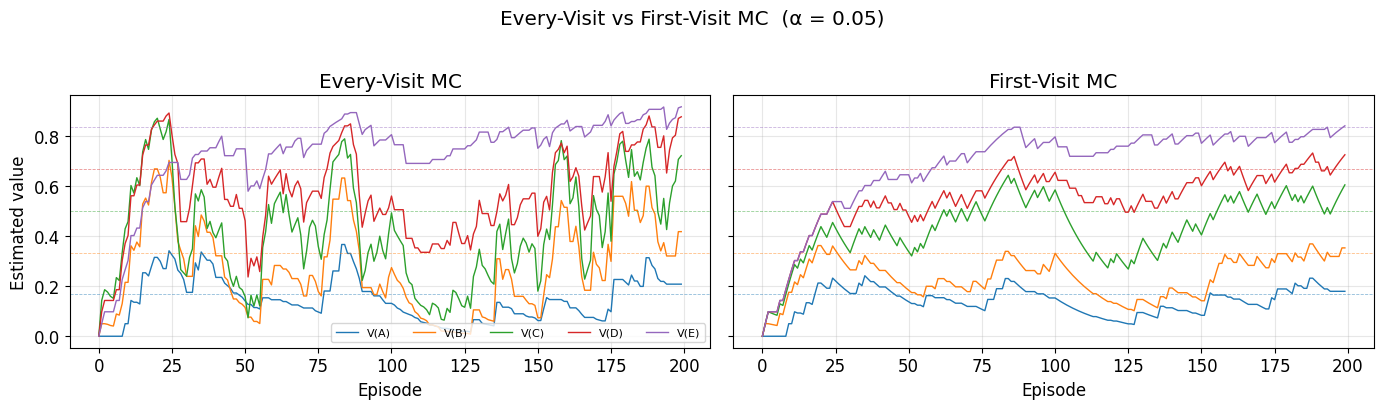

Final value estimates:
 State     True    Every    First
----------------------------------
     A   0.1667   0.2077   0.1791
     B   0.3333   0.4169   0.3522
     C   0.5000   0.7197   0.6033
     D   0.6667   0.8747   0.7233
     E   0.8333   0.9145   0.8387

RMS error — Every-visit: 0.1461   First-visit: 0.0537


In [36]:
# ── Run both methods on the same episodes ──
alpha = 0.05
n_episodes = 200
seed = 123

V_ev = mc_every_visit(alpha=alpha, n_episodes=n_episodes, seed=seed)
V_fv = mc_first_visit(alpha=alpha, n_episodes=n_episodes, seed=seed)

# ── Side-by-side learning curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for i, lbl in enumerate(state_labels):
    ax1.plot(V_ev[:, i], linewidth=1, label=f"V({lbl})")
    ax1.axhline(y=V_true[i], color=f"C{i}", linestyle="--", linewidth=0.6, alpha=0.5)
ax1.set_title("Every-Visit MC")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Estimated value")
ax1.legend(ncol=5, fontsize=8, loc="lower right")
ax1.grid(True, alpha=0.3)

for i, lbl in enumerate(state_labels):
    ax2.plot(V_fv[:, i], linewidth=1, label=f"V({lbl})")
    ax2.axhline(y=V_true[i], color=f"C{i}", linestyle="--", linewidth=0.6, alpha=0.5)
ax2.set_title("First-Visit MC")
ax2.set_xlabel("Episode")
ax2.grid(True, alpha=0.3)

fig.suptitle(f"Every-Visit vs First-Visit MC  (α = {alpha})", y=1.02)
plt.tight_layout()
plt.show()

# ── Print final values ──
print("Final value estimates:")
print(f"{'State':>6s}  {'True':>7s}  {'Every':>7s}  {'First':>7s}")
print("-" * 34)
for i, lbl in enumerate(state_labels):
    print(f"{lbl:>6s}  {V_true[i]:7.4f}  {V_ev[-1, i]:7.4f}  {V_fv[-1, i]:7.4f}")

# ── RMS error comparison ──
rms_ev = np.sqrt(np.mean((V_ev[-1] - V_true) ** 2))
rms_fv = np.sqrt(np.mean((V_fv[-1] - V_true) ** 2))
print(f"\nRMS error — Every-visit: {rms_ev:.4f}   First-visit: {rms_fv:.4f}")

> every-visit MC adds more variance in this example, because duplicated visits don't add more information.

## 4. TD(0)

TD(0) updates the value of each state after every step using the **one‑step
return** as the target:

$$V(S_t) \leftarrow V(S_t) + \alpha \big[ R_{t+1} + \gamma V(S_{t+1}) - V(S_t) \big]$$

In [37]:
def td_zero(
    alpha: float = 0.1,
    n_episodes: int = 100,
    n_states: int = 5,
    seed: int | None = None,
    initial_value: float = 0.0,
) -> np.ndarray:
    if seed is not None:
        np.random.seed(seed)

    env = RandomWalk(n_states)
    V = np.full(n_states, initial_value)
    V_history = np.zeros((n_episodes, n_states))

    for ep in range(n_episodes):
        state = env.reset()
        done = False

        while not done:
            next_state, reward, done = env.step()

            if next_state is not None:
                td_target = reward + V[next_state]  # γ = 1
            else:
                td_target = reward  # V(terminal) = 0

            td_error = td_target - V[state]
            V[state] += alpha * td_error

            if next_state is not None:
                state = next_state
            else:
                break

        V_history[ep] = V.copy()

    return V_history

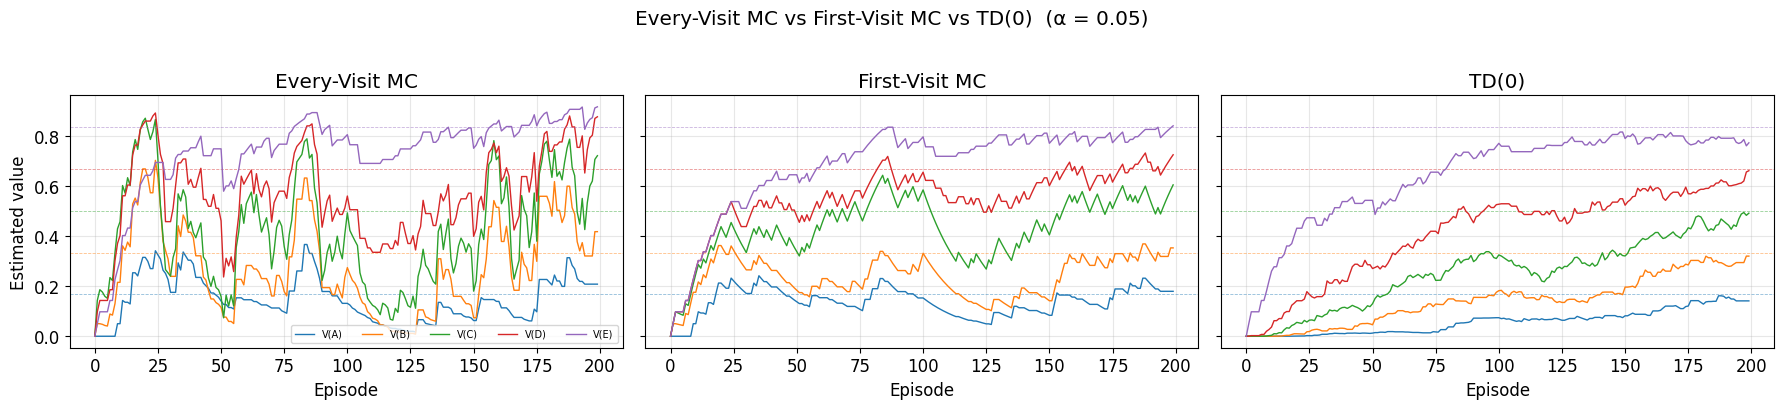

Final value estimates:
 State     True    Ev-MC    Fv-MC    TD(0)
--------------------------------------------
     A   0.1667   0.2077   0.1791   0.1410
     B   0.3333   0.4169   0.3522   0.3194
     C   0.5000   0.7197   0.6033   0.4906
     D   0.6667   0.8747   0.7233   0.6598
     E   0.8333   0.9145   0.8387   0.7710

RMS error — Every-visit MC: 0.1461   First-visit MC: 0.0537   TD(0): 0.0312


In [38]:
# ── Run all three methods on the same episodes ──
alpha = 0.05
n_episodes = 200
seed = 123

V_ev = mc_every_visit(alpha=alpha, n_episodes=n_episodes, seed=seed)
V_fv = mc_first_visit(alpha=alpha, n_episodes=n_episodes, seed=seed)
V_td = td_zero(alpha=alpha, n_episodes=n_episodes, seed=seed)

# ── Three-way learning curves ──
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for i, lbl in enumerate(state_labels):
    ax1.plot(V_ev[:, i], linewidth=1, label=f"V({lbl})")
    ax1.axhline(y=V_true[i], color=f"C{i}", linestyle="--", linewidth=0.6, alpha=0.5)
ax1.set_title("Every-Visit MC")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Estimated value")
ax1.legend(ncol=5, fontsize=7, loc="lower right")
ax1.grid(True, alpha=0.3)

for i, lbl in enumerate(state_labels):
    ax2.plot(V_fv[:, i], linewidth=1, label=f"V({lbl})")
    ax2.axhline(y=V_true[i], color=f"C{i}", linestyle="--", linewidth=0.6, alpha=0.5)
ax2.set_title("First-Visit MC")
ax2.set_xlabel("Episode")
ax2.grid(True, alpha=0.3)

for i, lbl in enumerate(state_labels):
    ax3.plot(V_td[:, i], linewidth=1, label=f"V({lbl})")
    ax3.axhline(y=V_true[i], color=f"C{i}", linestyle="--", linewidth=0.6, alpha=0.5)
ax3.set_title("TD(0)")
ax3.set_xlabel("Episode")
ax3.grid(True, alpha=0.3)

fig.suptitle(f"Every-Visit MC vs First-Visit MC vs TD(0)  (α = {alpha})", y=1.02)
plt.tight_layout()
plt.show()

# ── Print final values ──
print("Final value estimates:")
print(f"{'State':>6s}  {'True':>7s}  {'Ev-MC':>7s}  {'Fv-MC':>7s}  {'TD(0)':>7s}")
print("-" * 44)
for i, lbl in enumerate(state_labels):
    print(f"{lbl:>6s}  {V_true[i]:7.4f}  {V_ev[-1, i]:7.4f}  {V_fv[-1, i]:7.4f}  {V_td[-1, i]:7.4f}")

# ── RMS error comparison ──
rms_ev = np.sqrt(np.mean((V_ev[-1] - V_true) ** 2))
rms_fv = np.sqrt(np.mean((V_fv[-1] - V_true) ** 2))
rms_td = np.sqrt(np.mean((V_td[-1] - V_true) ** 2))
print(f"\nRMS error — Every-visit MC: {rms_ev:.4f}   First-visit MC: {rms_fv:.4f}   TD(0): {rms_td:.4f}")

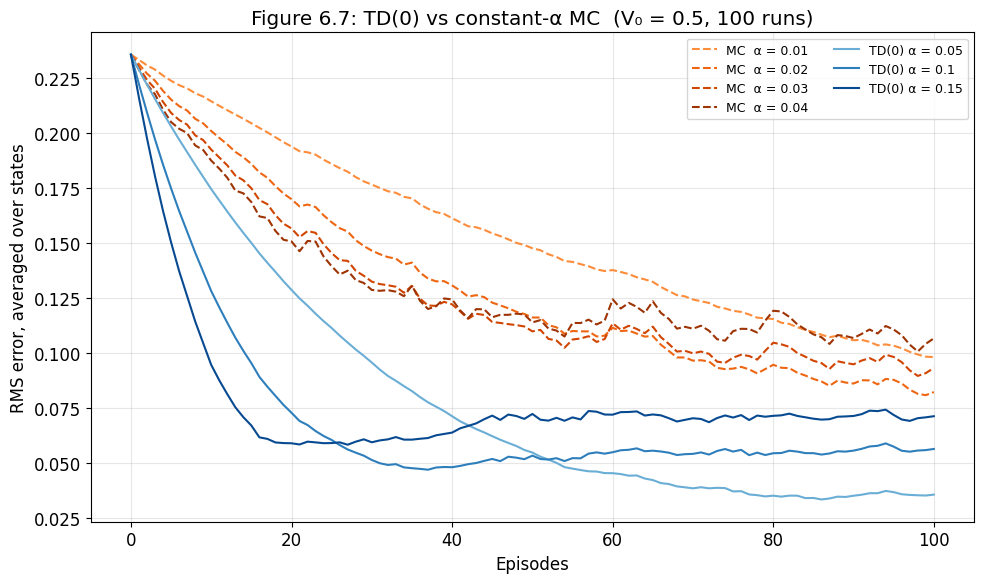

Best MC  α: 0.02  (final RMS = 0.0821)
Best TD  α: 0.05  (final RMS = 0.0355)


In [39]:
# ── Figure 6.7: TD(0) vs MC with V₀(s) = 0.5 ──
n_episodes = 100
n_runs = 100

alphas_mc = [0.01, 0.02, 0.03, 0.04]
alphas_td = [0.05, 0.10, 0.15]

# +1 to include the initial error at episode 0
rms_mc = np.zeros((len(alphas_mc), n_runs, n_episodes + 1))
rms_td = np.zeros((len(alphas_td), n_runs, n_episodes + 1))

initial_rms = np.sqrt(np.mean((0.5 - V_true) ** 2))
rms_mc[:, :, 0] = initial_rms
rms_td[:, :, 0] = initial_rms

for run in range(n_runs):
    for i, a in enumerate(alphas_mc):
        V_hist = mc_every_visit(alpha=a, n_episodes=n_episodes, seed=run, initial_value=0.5)
        rms_mc[i, run, 1:] = np.sqrt(np.mean((V_hist - V_true) ** 2, axis=1))
    for i, a in enumerate(alphas_td):
        V_hist = td_zero(alpha=a, n_episodes=n_episodes, seed=run, initial_value=0.5)
        rms_td[i, run, 1:] = np.sqrt(np.mean((V_hist - V_true) ** 2, axis=1))

# ── Plot: all curves on one figure ──
episodes = np.arange(0, n_episodes + 1)
fig, ax = plt.subplots(figsize=(10, 6))

mc_colors = plt.cm.Oranges(np.linspace(0.5, 0.9, len(alphas_mc)))
td_colors = plt.cm.Blues(np.linspace(0.5, 0.9, len(alphas_td)))

for i, (a, c) in enumerate(zip(alphas_mc, mc_colors)):
    mean = rms_mc[i].mean(axis=0)
    ax.plot(episodes, mean, linewidth=1.5, color=c, label=f"MC  α = {a}", linestyle="--")

for i, (a, c) in enumerate(zip(alphas_td, td_colors)):
    mean = rms_td[i].mean(axis=0)
    ax.plot(episodes, mean, linewidth=1.5, color=c, label=f"TD(0) α = {a}")

ax.set_xlabel("Episodes")
ax.set_ylabel("RMS error, averaged over states")
ax.set_title(f"Figure 6.7: TD(0) vs constant-α MC  (V₀ = 0.5, {n_runs} runs)")
ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Best α from each ──
best_mc_idx = np.argmin(rms_mc[:, :, -1].mean(axis=1))
best_td_idx = np.argmin(rms_td[:, :, -1].mean(axis=1))
print(f"Best MC  α: {alphas_mc[best_mc_idx]}  (final RMS = {rms_mc[best_mc_idx, :, -1].mean():.4f})")
print(f"Best TD  α: {alphas_td[best_td_idx]}  (final RMS = {rms_td[best_td_idx, :, -1].mean():.4f})")

## 5. n-Step TD

The n-step return from time \(t\) bridges TD(0) and MC:

$$G_{t:t+n} = R_{t+1} + \gamma R_{t+2} + \cdots + \gamma^{n-1} R_{t+n} + \gamma^n V(S_{t+n})$$

In the random walk all intermediate rewards are zero, so for \($\gamma$ = 1\):

$$G_{t:t+n} = \begin{cases} V(S_{t+n}), & t+n < T \\ R_T, & t+n \ge T \end{cases}$$

Below: 19 states, rewards −1 (left) / +1 (right), V₀ = 0.  We sweep over
**n** and **α**, measuring the RMS error averaged over the first 10 episodes
and 100 repetitions — reproducing Figure 7.2 from Sutton &amp; Barto.

n =   1  done
n =   2  done
n =   4  done
n =   8  done
n =  16  done
n =  32  done
n =  64  done
n = 128  done
n = 256  done
n = 512  done


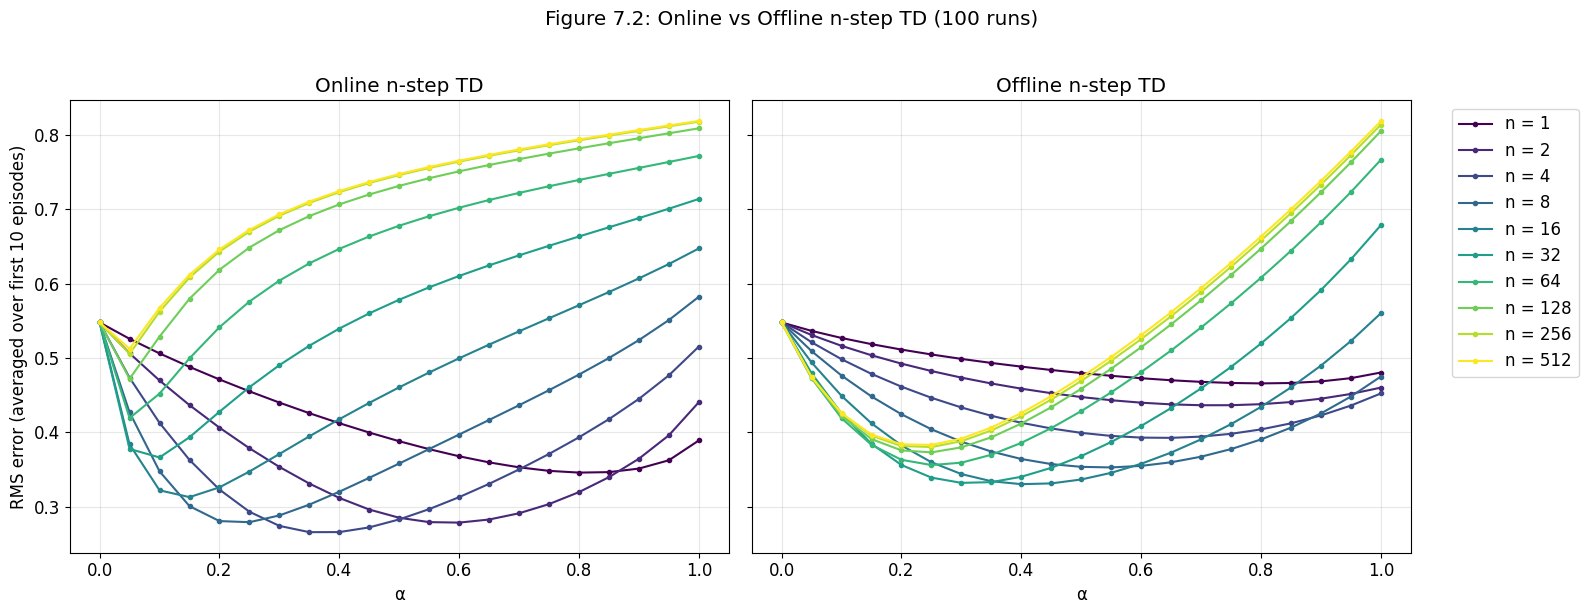

Online  best: n =   4, α = 0.35   (RMS = 0.2659)
Offline best: n =  16, α = 0.40   (RMS = 0.3304)


In [40]:
# ── Figure 7.2: online vs offline n-step TD on 19-state random walk ──
# 19 states, left reward = -1, right reward = +1, V₀ = 0


def n_step_td_online(alpha, n, n_episodes, seed=None):
    if seed is not None:
        np.random.seed(seed)
    env = RandomWalk(n_states=19, left_reward=-1.0, right_reward=1.0)
    V = np.zeros(19)
    V_history = np.zeros((n_episodes, 19))
    for ep in range(n_episodes):
        states, final_reward = env.generate_episode()
        T = len(states)
        for t in range(T):
            if t + n < T:
                G = V[states[t + n]]  # bootstrap — uses latest V
            else:
                G = final_reward
            V[states[t]] += alpha * (G - V[states[t]])
        V_history[ep] = V.copy()
    return V_history


def n_step_td_offline(alpha, n, n_episodes, seed=None):
    if seed is not None:
        np.random.seed(seed)
    env = RandomWalk(n_states=19, left_reward=-1.0, right_reward=1.0)
    V = np.zeros(19)
    V_history = np.zeros((n_episodes, 19))
    for ep in range(n_episodes):
        states, final_reward = env.generate_episode()
        T = len(states)
        V_old = V.copy()  # snapshot at episode start
        seen = set()
        for t in range(T):
            s = states[t]
            if s not in seen:  # first-visit — one update per state per episode
                seen.add(s)
                if t + n < T:
                    G = V_old[states[t + n]]
                else:
                    G = final_reward
                V[s] += alpha * (G - V_old[s])
        V_history[ep] = V.copy()
    return V_history


# True values for the 19-state walk  (V(s_i) = (i - 9) / 10)
V_true_19 = np.array([(i - 9) / 10 for i in range(19)])

# ── Sweep ──
n_values = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
alphas = np.arange(0.0, 1.05, 0.05)
n_runs = 100
n_episodes = 10

rms_on = np.zeros((len(n_values), len(alphas)))
rms_off = np.zeros((len(n_values), len(alphas)))

for ni, n in enumerate(n_values):
    for ai, a in enumerate(alphas):
        errs_on = np.zeros(n_runs)
        errs_off = np.zeros(n_runs)
        for run in range(n_runs):
            V_on = n_step_td_online(alpha=a, n=n, n_episodes=n_episodes, seed=run)
            V_off = n_step_td_offline(alpha=a, n=n, n_episodes=n_episodes, seed=run)
            errs_on[run] = np.sqrt(np.mean((V_on - V_true_19) ** 2, axis=1)).mean()
            errs_off[run] = np.sqrt(np.mean((V_off - V_true_19) ** 2, axis=1)).mean()
        rms_on[ni, ai] = errs_on.mean()
        rms_off[ni, ai] = errs_off.mean()
    print(f"n = {n:3d}  done")

# ── Plot side by side ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(n_values)))

for ni, (n, c) in enumerate(zip(n_values, colors)):
    ax1.plot(alphas, rms_on[ni], linewidth=1.5, color=c, marker="o", markersize=3, label=f"n = {n}")
    ax2.plot(alphas, rms_off[ni], linewidth=1.5, color=c, marker="o", markersize=3, label=f"n = {n}")

ax1.set_title("Online n-step TD")
ax1.set_xlabel("α")
ax1.set_ylabel("RMS error (averaged over first 10 episodes)")
ax1.grid(True, alpha=0.3)

ax2.set_title("Offline n-step TD")
ax2.set_xlabel("α")
ax2.grid(True, alpha=0.3)

fig.suptitle(f"Figure 7.2: Online vs Offline n-step TD ({n_runs} runs)", y=1.02)
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ── Best ──
best_on = np.unravel_index(np.argmin(rms_on), rms_on.shape)
best_off = np.unravel_index(np.argmin(rms_off), rms_off.shape)
print(f"Online  best: n = {n_values[best_on[0]]:3d}, α = {alphas[best_on[1]]:.2f}   (RMS = {rms_on.min():.4f})")
print(f"Offline best: n = {n_values[best_off[0]]:3d}, α = {alphas[best_off[1]]:.2f}   (RMS = {rms_off.min():.4f})")

## 6. TD(λ) — Eligibility Traces

TD(λ) interpolates between TD(0) (λ = 0) and Monte Carlo (λ = 1) by
blending *n*‑step returns:

$$G_t^\lambda = (1-\lambda) \sum_{n=1}^{\infty} \lambda^{\,n-1} G_{t:t+n}$$

### Backward view (practical implementation)

Maintain an **eligibility trace** *E(s)* for each state — a decaying memory of
recent visits.  On each step the TD error is broadcast to all states in
proportion to their trace:

$$\begin{aligned}
E_t(s) &= \gamma\lambda E_{t-1}(s) + \mathbb{1}\{S_t = s\} \\
V(s) &\leftarrow V(s) + \alpha \,\delta_t\, E_t(s)
\end{aligned}$$

In [43]:
def td_lambda(
    alpha: float = 0.1,
    lam: float = 0.5,
    n_episodes: int = 100,
    n_states: int = 5,
    seed: int | None = None,
    initial_value: float = 0.0,
    left_reward: float = 0.0,
    right_reward: float = 1.0,
) -> np.ndarray:
    """Online TD(λ) — backward view with replacing eligibility traces."""
    if seed is not None:
        np.random.seed(seed)
    env = RandomWalk(n_states, left_reward=left_reward, right_reward=right_reward)
    V = np.full(n_states, initial_value)
    V_history = np.zeros((n_episodes, n_states))
    for ep in range(n_episodes):
        state = env.reset()
        E = np.zeros(n_states)
        done = False
        while not done:
            next_state, reward, done = env.step()
            if next_state is not None:
                td_target = reward + V[next_state]
            else:
                td_target = reward
            td_error = td_target - V[state]
            E[state] = 1  # replacing trace — at most 1, prevents explosion
            V += alpha * td_error * E
            E *= lam
            if next_state is not None:
                state = next_state
            else:
                break
        V_history[ep] = V.copy()
    return V_history


def td_lambda_offline(
    alpha: float = 0.1,
    lam: float = 0.5,
    n_episodes: int = 100,
    n_states: int = 5,
    seed: int | None = None,
    initial_value: float = 0.0,
    left_reward: float = 0.0,
    right_reward: float = 1.0,
) -> np.ndarray:
    """Offline TD(λ) — λ-returns computed from V_old, first-visit updates."""
    if seed is not None:
        np.random.seed(seed)
    env = RandomWalk(n_states, left_reward=left_reward, right_reward=right_reward)
    V = np.full(n_states, initial_value)
    V_history = np.zeros((n_episodes, n_states))
    for ep in range(n_episodes):
        states, final_reward = env.generate_episode()
        T = len(states)
        V_old = V.copy()
        seen = set()
        for t in range(T):
            s = states[t]
            if s not in seen:
                seen.add(s)
                # compute λ-return  G_t^λ = (1-λ) Σ λ^{k-1} V(S_{t+k}) + λ^{T-t-1} R_T
                G = 0.0
                for k in range(1, T - t):
                    G += lam ** (k - 1) * V_old[states[t + k]]
                G = (1 - lam) * G + lam ** max(T - t - 1, 0) * final_reward
                V[s] += alpha * (G - V_old[s])
        V_history[ep] = V.copy()
    return V_history

λ = 0.00  done
λ = 0.20  done
λ = 0.40  done
λ = 0.60  done
λ = 0.80  done
λ = 0.90  done
λ = 0.95  done
λ = 0.99  done
λ = 1.00  done


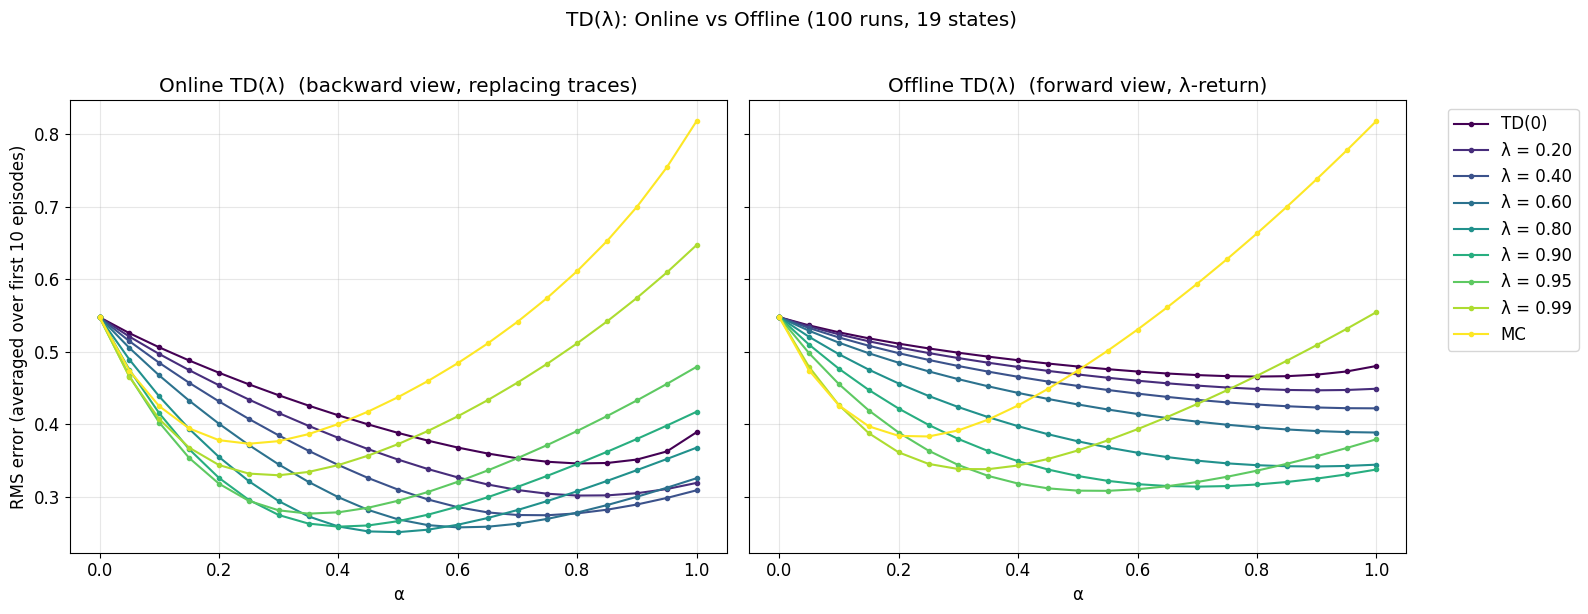

Online  best: λ = 0.80, α = 0.50   (RMS = 0.2511)
Offline best: λ = 0.95, α = 0.55   (RMS = 0.3082)


In [42]:
# ── TD(λ) sweep: online vs offline on 19-state random walk ──
# 19 states, left reward = -1, right reward = +1, V₀ = 0

V_true_19 = np.array([(i - 9) / 10 for i in range(19)])

lam_values = [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0]
alphas = np.arange(0.0, 1.05, 0.05)
n_runs = 100
n_episodes = 10

rms_on = np.zeros((len(lam_values), len(alphas)))
rms_off = np.zeros((len(lam_values), len(alphas)))

for li, lam in enumerate(lam_values):
    for ai, a in enumerate(alphas):
        errs_on = np.zeros(n_runs)
        errs_off = np.zeros(n_runs)
        for run in range(n_runs):
            V_on = td_lambda(alpha=a, lam=lam, n_episodes=n_episodes, n_states=19, seed=run, initial_value=0.0, left_reward=-1.0, right_reward=1.0)
            V_off = td_lambda_offline(
                alpha=a, lam=lam, n_episodes=n_episodes, n_states=19, seed=run, initial_value=0.0, left_reward=-1.0, right_reward=1.0
            )
            errs_on[run] = np.sqrt(np.mean((V_on - V_true_19) ** 2, axis=1)).mean()
            errs_off[run] = np.sqrt(np.mean((V_off - V_true_19) ** 2, axis=1)).mean()
        rms_on[li, ai] = errs_on.mean()
        rms_off[li, ai] = errs_off.mean()
    print(f"λ = {lam:.2f}  done")

# ── Plot side by side ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(lam_values)))

for li, (lam, c) in enumerate(zip(lam_values, colors)):
    label = "TD(0)" if lam == 0.0 else "MC" if lam == 1.0 else f"λ = {lam:.2f}"
    ax1.plot(alphas, rms_on[li], linewidth=1.5, color=c, marker="o", markersize=3, label=label)
    ax2.plot(alphas, rms_off[li], linewidth=1.5, color=c, marker="o", markersize=3, label=label)

ax1.set_title("Online TD(λ)  (backward view, replacing traces)")
ax1.set_xlabel("α")
ax1.set_ylabel("RMS error (averaged over first 10 episodes)")
ax1.grid(True, alpha=0.3)

ax2.set_title("Offline TD(λ)  (forward view, λ-return)")
ax2.set_xlabel("α")
ax2.grid(True, alpha=0.3)

fig.suptitle(f"TD(λ): Online vs Offline ({n_runs} runs, 19 states)", y=1.02)
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ── Best ──
best_on = np.unravel_index(np.argmin(rms_on), rms_on.shape)
best_off = np.unravel_index(np.argmin(rms_off), rms_off.shape)
print(f"Online  best: λ = {lam_values[best_on[0]]:.2f}, α = {alphas[best_on[1]]:.2f}   (RMS = {rms_on.min():.4f})")
print(f"Offline best: λ = {lam_values[best_off[0]]:.2f}, α = {alphas[best_off[1]]:.2f}   (RMS = {rms_off.min():.4f})")

---
**Reference**: Sutton, R. S. & Barto, A. G.  *Reinforcement Learning:
An Introduction*, 2nd ed., Chapter 6 (TD Learning) and Chapter 7
(Eligibility Traces).